# Assignment 2: Structural Defect Identification
## A hands-on solution for detecting cracks in concrete

**Audience:** Mechanical engineering students learning Python and machine learning.

**Question:** Given one concrete image, can a model identify whether it contains a crack?

The notebook contains the implementation, explanations, evaluation, and report for the assignment.
The class labels are **0 = cracked** and **1 = not cracked** throughout.

## Introduction

Concrete crack detection is an image-classification problem: an input image is assigned to one of two categories.
The objective here is to classify image patches of bridge decks, walls, and pavements using the supplied SDNET2018 archive.
We use MobileNetV2, a neural network with features already learned from ImageNet, rather than start all model weights from random values.
We replace its original classifier with the exact classification head specified in the assignment.
First, we train the new head for five epochs while the pretrained base is frozen.
Next, we fine-tune part of the base for three more epochs at a lower learning rate.
We keep training, validation, and test examples separate and pay particular attention to missed cracks.

This is **patch-level classification**, not a crack-location or crack-width measurement system.
A correct program and a complete analysis do not imply that every image will be classified correctly.
This exercise does not establish structural capacity or suitability for autonomous field inspection.

## Before running the code

In Colab, select **Runtime > Change runtime type > GPU**, then run the cells from top to bottom.
The setup cell checks the GPU that TensorFlow actually detects. It does not assume that the device is an A100.
The default settings use all supplied images, 64 x 64 pixels, batches of 8, five transfer-learning epochs, and three fine-tuning epochs.
Internet access is needed to download the course data and the ImageNet weights.
The code uses the libraries already provided by Colab; it does not install a different TensorFlow or CUDA version.

Official resources: [Colab FAQ](https://research.google.com/colaboratory/faq.html) and
[TensorFlow GPU guide](https://www.tensorflow.org/guide/gpu).

## Dataset description

The [Utah State University SDNET2018 record](https://digitalcommons.usu.edu/all_datasets/48/) describes more than
56,000 annotated images of cracked and non-cracked bridge decks, walls, and pavements.
It reports crack widths from 0.06 to 25 mm and difficult conditions including shadows, rough surfaces, edges, and debris.
The source photographs were divided into 256 x 256 image patches. This assignment resizes the patches to 64 x 64.
The assignment also directs readers to the [Kaggle dataset page](https://www.kaggle.com/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images).
The university record is the source for the descriptive details above.

We download the **course-provided archive**, which already has `train` and `test` folders, and count what it actually contains.
The supplied completed run loaded **56,085 images**, comprising 44,868 original training images and 11,217 test images.
Published counts and counts in a redistributed course archive should not be silently treated as identical.

Different patches can originate from related photographs or structures. Checking that file paths are different does not
prove that source photographs or structures are independent. We retain the supplied test split and acknowledge this limitation.

Dataset citation: Maguire, M., Dorafshan, S., and Thomas, R. J. (2018).
*SDNET2018: A concrete crack image dataset for machine learning applications*. Utah State University.
[Dataset DOI](https://doi.org/10.15142/T3TD19).

## Model / Method

We reserve 20% of the original training folder for validation using a fixed random seed and **stratification**.
Stratification keeps approximately the same cracked/non-cracked proportion in both subsets.
The test folder is not used to change learning rates, choose weights, or choose a classification threshold.
After checking both classes are present, we compute class weights using only the actual training subset.

We retain the assignment's image size, batch size, division by 255, and flip/90-degree-rotation operations.
The implementation deliberately improves their ordering: cache clean images first, then shuffle and randomly augment only training images.
We add a nontrainable `2*x - 1` layer inside the model to turn the supplied `[0, 1]` inputs into MobileNetV2's expected `[-1, 1]` range.
The classifier head is `GlobalAveragePooling2D -> Dense(512, ReLU) -> Dropout(0.25) -> Dense(256, ReLU) -> Dropout(0.25) -> Dense(1, sigmoid)`.
An L2 penalty of 0.0001 is an additional design choice; dropout already supplies regularization.

Adam starts at 0.001 for the five-epoch head-training phase and 0.00001 for the three-epoch fine-tuning phase.
Fine-tuning starts at block 14. Earlier layers and BatchNormalization layers stay frozen.
Callbacks save the best weights and reduce the learning rate using **validation unweighted binary cross-entropy**.
This is a separate metric that excludes class weights and the L2 penalty; lower is better.
The best checkpoint from either stage is selected by this metric before test evaluation.
A fixed non-cracked-score threshold of 0.5 is used; exact ties are assigned to cracked, consistently with Keras BinaryAccuracy.

Official explanations: [stratified splitting](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html),
[avoiding data leakage](https://scikit-learn.org/stable/common_pitfalls.html),
[MobileNetV2 preprocessing](https://keras.io/api/applications/mobilenet/mobilenet_models/),
[transfer learning](https://keras.io/guides/transfer_learning/).

## 1. Data retrieval and preprocessing
### 1.1 Import tools and select the experiment settings

Four main scientific tools do the work: **TensorFlow/Keras** builds and trains the model, **NumPy** handles numerical arrays,
**Matplotlib** makes plots, and **scikit-learn** splits the data and calculates evaluation metrics.
The other imports below are small Python utilities for files, ZIP archives, and timestamps.
All important numerical choices are stored at the top so they are easy to find.

In [ ]:
# Import Python's file, time, and ZIP utilities.
# These are included with Python and do not need a separate installation.
import os
import time
import glob
import zipfile

# Import the four main scientific libraries used in this solution.
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Use one seed to make random choices more repeatable.
# The same seed does not guarantee identical numbers on every GPU/software version.
SEED = 42

# Keep the image and batch sizes supplied in the assignment.
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 8

# Reserve 20% of the original TRAINING folder for validation.
# The existing TEST folder remains untouched for final evaluation.
VALIDATION_FRACTION = 0.20

# Run exactly the two epoch budgets requested in the assignment.
TRANSFER_EPOCHS = 5
FINE_TUNE_EPOCHS = 3

# A learning rate controls the size of an optimizer's weight adjustments.
TRANSFER_LEARNING_RATE = 0.001
FINE_TUNE_LEARNING_RATE = 0.00001

# L2 is an optional additional penalty on large hidden-layer weights.
L2_STRENGTH = 0.0001

# Class 0 always means cracked; class 1 always means not cracked.
CLASS_NAMES = ["cracked", "not-cracked"]

# The sigmoid output is a score for class 1, NOT the cracked class.
# We predict not cracked only when that score is greater than 0.5.
THRESHOLD = 0.5

# Caching clean 64 x 64 RGB float32 images takes about 2.57 GiB for this archive.
# Set this to False and restart the run if the Colab session has insufficient RAM.
CACHE_IMAGES = True

# Use a small fixed number of CPU workers for loading/augmenting images.
# The GPU is used for the neural network calculations, not for downloading files.
DATA_WORKERS = 4

# Keep all generated files inside one dedicated workspace.
WORK_DIR = "/content/assignment2_solution"
DATA_DIR = os.path.join(WORK_DIR, "data")

# Each run receives a different output directory based on the current clock.
# This prevents old checkpoints from being mistaken for new results.
RUN_ID = str(time.time_ns())
RUN_DIR = os.path.join(WORK_DIR, "runs", RUN_ID)
os.makedirs(RUN_DIR, exist_ok=True)

# Use the exact data URL supplied in the assignment.
DATA_URL = "https://storage.googleapis.com/535743/module02/sdn.zip"
print("Results from this run will be saved in:", RUN_DIR)

Results from this run will be saved in: /content/assignment2_solution/runs/1790248322799944549


### 1.2 Verify the GPU before training

Selecting a GPU in Colab and having TensorFlow detect that GPU are different checks.
The next cell records the library versions and performs one small GPU calculation.
An empty GPU list means that this session does not meet the assignment's GPU requirement.
Restart the session and run from the top rather than relying on variables left over from an earlier session.

Resources: [TensorFlow GPU setup](https://www.tensorflow.org/guide/gpu),
[random seeds](https://www.tensorflow.org/api_docs/python/tf/keras/utils/set_random_seed).

In [ ]:
# Clear any previous Keras model state when starting a new experiment.
tf.keras.backend.clear_session()

# Ask TensorFlow which physical GPUs it can access.
gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus)
assert len(gpus) > 0, "Select a GPU runtime in Colab, then restart and run from the top."

# Let TensorFlow request GPU memory as needed rather than reserving it all at once.
# A previously initialized runtime may not allow changing this setting.
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        print("GPU memory settings are already initialized in this session.")

# Set random seeds after clearing the previous model state.
tf.keras.utils.set_random_seed(SEED)

# Use ordinary 32-bit numbers; mixed precision is not needed for this lesson.
tf.keras.mixed_precision.set_global_policy("float32")

# Record the detected GPU name rather than assuming T4, L4, or A100.
gpu_details = tf.config.experimental.get_device_details(gpus[0])
gpu_name = gpu_details.get("device_name", "Detected GPU")

# This small calculation confirms actual GPU placement.
with tf.device("/GPU:0"):
    gpu_check = tf.matmul(tf.ones((4, 4)), tf.ones((4, 4)))
assert "GPU" in gpu_check.device, "The verification calculation did not run on the GPU."

# Print and save the environment used in THIS execution.
print("GPU:", gpu_name)
print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("NumPy:", np.__version__)
print("GPU verification device:", gpu_check.device)
with open(os.path.join(RUN_DIR, "environment.txt"), "w") as file:
    file.write("GPU: " + gpu_name + "\n")
    file.write("TensorFlow: " + tf.__version__ + "\n")
    file.write("Keras: " + tf.keras.__version__ + "\n")
    file.write("NumPy: " + np.__version__ + "\n")

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU: Tesla T4
TensorFlow: 2.20.0
Keras: 3.13.2
NumPy: 2.1.3
GPU verification device: /job:localhost/replica:0/task:0/device:GPU:0


### 1.3 Download the course archive

`get_file` is Keras's download helper. It downloads the same ZIP file as the assignment's `wget` command and reuses a cached download.
`ZipFile` opens that archive. Extraction happens in a dedicated directory, not over unrelated personal files.
The completion marker is written only after extraction succeeds; the original ZIP is retained for reuse.
These are convenience changes to the supplied download script, not a different dataset.

Resources: [Keras get_file](https://keras.io/api/utils/python_utils/),
[Python ZIP files](https://docs.python.org/3/library/zipfile.html),
[Python file handling](https://docs.python.org/3/tutorial/inputoutput.html#reading-and-writing-files).

In [ ]:
# Make the dedicated data directory if it does not exist yet.
os.makedirs(DATA_DIR, exist_ok=True)
ready_file = os.path.join(DATA_DIR, "extraction_completed.txt")

# Reuse an extraction only when the previous extraction finished successfully.
if not os.path.isfile(ready_file):
    archive_path = tf.keras.utils.get_file(
        fname="sdn.zip",
        origin=DATA_URL,
        cache_dir=WORK_DIR,
        cache_subdir="download"
    )

    # Check the ZIP before writing the completion marker.
    with zipfile.ZipFile(archive_path, "r") as archive:
        bad_member = archive.testzip()
        assert bad_member is None, "The downloaded ZIP is damaged. Download it again."

        # Reject unexpected archive paths that point outside our dedicated folder.
        # This is a file-safety check, not a machine-learning operation.
        for member_name in archive.namelist():
            destination = os.path.abspath(os.path.join(DATA_DIR, member_name))
            assert os.path.commonpath([DATA_DIR, destination]) == DATA_DIR, "Unsafe ZIP path."

        archive.extractall(DATA_DIR)

    # Check the expected course folder structure before recording success.
    for split_name in ["train", "test"]:
        for class_name in CLASS_NAMES:
            folder = os.path.join(DATA_DIR, split_name, class_name)
            assert os.path.isdir(folder), "Missing dataset folder: " + folder

    with open(ready_file, "w") as file:
        file.write("Course SDNET2018 archive extracted successfully.\n")
else:
    print("Reusing the completed extraction in", DATA_DIR)

# A later cell also checks file counts and the presence of both classes.
for split_name in ["train", "test"]:
    for class_name in CLASS_NAMES:
        folder = os.path.join(DATA_DIR, split_name, class_name)
        assert os.path.isdir(folder), "Missing dataset folder: " + folder

print("SDNET2018 is ready.")

Reusing the completed extraction in /content/assignment2_solution/data
SDNET2018 is ready.


### 1.4 Count images using glob and create matching file/label lists

A **file path** is the location of an image on disk. We split these small path lists before loading every image into memory.
`glob` searches for files using a pattern; `**` means search subfolders too when `recursive=True`.
The helper below retains supported image files and ignores unrelated files.
The TensorFlow directory loader is also used to confirm the category mapping and file counts.
Its `utils` name is the public alias of the loader used in the assignment.

Resources: [glob](https://docs.python.org/3/library/glob.html),
[image_dataset_from_directory](https://keras.io/api/data_loading/image/).

In [ ]:
# Define a small reusable function instead of repeating file-search code.
# The function returns a sorted list of supported image file paths.
def find_images(folder):
    image_files = []
    candidates = glob.glob(os.path.join(folder, "**", "*"), recursive=True)
    for path in candidates:
        extension = os.path.splitext(path)[1].lower()
        if os.path.isfile(path) and extension in [".jpg", ".jpeg", ".png", ".bmp", ".gif"]:
            image_files.append(path)
    return sorted(image_files)

# Fix the class order explicitly; do not guess what labels 0 and 1 mean.
train_directory = os.path.join(DATA_DIR, "train")
test_directory = os.path.join(DATA_DIR, "test")

# Use the directory loader to obtain the original, ordered file lists.
# batch_size=None gives individual examples rather than preformed batches.
# shuffle=False is safe here because we will RANDOMLY STRATIFY the file list later.
original_train = tf.keras.utils.image_dataset_from_directory(
    train_directory, class_names=CLASS_NAMES, image_size=IMAGE_SIZE,
    label_mode="binary", batch_size=None, shuffle=False
)
original_test = tf.keras.utils.image_dataset_from_directory(
    test_directory, class_names=CLASS_NAMES, image_size=IMAGE_SIZE,
    label_mode="binary", batch_size=None, shuffle=False
)

# Each file must retain the label from its class folder.
all_train_paths = np.array(original_train.file_paths)
test_paths = np.array(original_test.file_paths)
all_train_labels = []
test_labels = []

for path in all_train_paths:
    relative_path = os.path.relpath(path, train_directory)
    folder_name = relative_path.split(os.sep)[0]
    all_train_labels.append(CLASS_NAMES.index(folder_name))

for path in test_paths:
    relative_path = os.path.relpath(path, test_directory)
    folder_name = relative_path.split(os.sep)[0]
    test_labels.append(CLASS_NAMES.index(folder_name))

# Convert label lists into integer arrays: one label per image.
all_train_labels = np.array(all_train_labels, dtype=np.int32)
test_labels = np.array(test_labels, dtype=np.int32)

# Count with glob as requested, and compare those counts with the loader.
for class_number in [0, 1]:
    class_name = CLASS_NAMES[class_number]
    train_count = len(find_images(os.path.join(train_directory, class_name)))
    test_count = len(find_images(os.path.join(test_directory, class_name)))
    assert train_count == int(np.sum(all_train_labels == class_number))
    assert test_count == int(np.sum(test_labels == class_number))
    print("Class", class_number, "=", class_name)
    print("  Original training images:", train_count)
    print("  Reserved test images:", test_count)

print("Total original training images:", len(all_train_paths))
print("Total test images:", len(test_paths))

# These temporary loader objects are not used to train the model.
# The new streams below will follow the fixed file split.
del original_train, original_test

Found 44868 files belonging to 2 classes.
Found 11217 files belonging to 2 classes.
Class 0 = cracked
  Original training images: 6788
  Reserved test images: 1696
Class 1 = not-cracked
  Original training images: 38080
  Reserved test images: 9521
Total original training images: 44868
Total test images: 11217


### 1.5 Split training examples, then check the actual subsets

For classification, a random split should preserve both classes. `stratify=all_train_labels` requests approximately the same class proportions.
Do not take the first 20% of an unshuffled class-ordered dataset: that can put every cracked image in validation.
`random_state=SEED` makes the split repeatable when the input file list is unchanged.
Although the library function is called `train_test_split`, we use it here to make **training and validation** subsets only.
The separate course test set is not split or used for model development.

Resource: [train_test_split parameters](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [ ]:
# Split paths and labels TOGETHER so that every label stays with its image.
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths,
    all_train_labels,
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    shuffle=True,
    stratify=all_train_labels
)

# Give validation files a stable sorted order; labels must use the same ordering.
# Training retains the split's randomized order before its later batch shuffling.
val_order = np.argsort(val_paths)
val_paths = val_paths[val_order]
val_labels = val_labels[val_order]

# Check that no original training image has been discarded.
assert len(train_paths) + len(val_paths) == len(all_train_paths)

# Check for repeated paths and training/validation overlap.
assert len(np.unique(all_train_paths)) == len(all_train_paths)
assert len(np.unique(test_paths)) == len(test_paths)
assert len(np.intersect1d(train_paths, val_paths)) == 0
assert len(np.intersect1d(train_paths, test_paths)) == 0
assert len(np.intersect1d(val_paths, test_paths)) == 0

# np.sum(labels == 0) counts how many labels equal zero.
# Verify the ACTUAL subsets, not just the original folders.
for name, labels in [("Training", train_labels), ("Validation", val_labels), ("Test", test_labels)]:
    cracked_count = int(np.sum(labels == 0))
    not_cracked_count = int(np.sum(labels == 1))
    assert cracked_count > 0 and not_cracked_count > 0, name + " must contain both classes."
    print(name, ":", cracked_count, "cracked +", not_cracked_count, "not cracked =", len(labels))
    print("  Cracked share:", round(100 * cracked_count / len(labels), 2), "%")

# Save the exact image membership to make this experiment auditable.
# Each row in these supplemental CSV files contains one path and its label.
for name, paths, labels in [("training", train_paths, train_labels),
                            ("validation", val_paths, val_labels),
                            ("test", test_paths, test_labels)]:
    rows = np.column_stack((paths, labels))
    np.savetxt(os.path.join(RUN_DIR, name + "_files.csv"), rows,
               fmt="%s", delimiter=",", header="path,label", comments="")

Training : 5430 cracked + 30464 not cracked = 35894
  Cracked share: 15.13 %
Validation : 1358 cracked + 7616 not cracked = 8974
  Cracked share: 15.13 %
Test : 1696 cracked + 9521 not cracked = 11217
  Cracked share: 15.12 %


### 1.6 Account for class imbalance during training

The data are imbalanced when one category contains many more images than the other.
The recorded archive has about 5.6 non-cracked training images per cracked image.
The formula below gives the less frequent class a larger contribution to the training loss:

$$w_c = \frac{N}{2N_c}.$$

Here, `N` is the number of **actual training** examples and `N_c` is the number in class `c`.
This does not add new examples, guarantee better crack detection, or change the labels.
Validation and test metrics will remain unweighted so they describe the supplied sample distributions.

Resource: [Keras class_weight and weighted_metrics](https://keras.io/api/models/model_training_apis/).

In [ ]:
# Compute class counts using only the actual training subset.
number_cracked = int(np.sum(train_labels == 0))
number_not_cracked = int(np.sum(train_labels == 1))
number_training = len(train_labels)

# Store one weight for each label in a dictionary.
class_weight = {
    0: number_training / (2 * number_cracked),
    1: number_training / (2 * number_not_cracked)
}

print("Class 0 is cracked. Class 1 is not cracked.")
print("Training ratio, not cracked / cracked:", round(number_not_cracked / number_cracked, 2))
print("This dataset is not balanced.")
print("Training class weights:", class_weight)

# With this formula, the TOTAL weight assigned to each class is the same.
assert np.isclose(class_weight[0] * number_cracked, class_weight[1] * number_not_cracked)

Class 0 is cracked. Class 1 is not cracked.
Training ratio, not cracked / cracked: 5.61
This dataset is not balanced.
Training class weights: {0: 3.305156537753223, 1: 0.5891215861344538}


### 1.7 Turn a file into a tensor

A color image is a three-dimensional array: **height x width x color channels**.
Here, one image has shape `(64, 64, 3)`, where the three channels are red, green, and blue.
A batch usually has shape `(8, 64, 64, 3)`. Its labels have shape `(8, 1)`.
The final batch can contain fewer than eight images; it is kept, not discarded.

We read file bytes, decode them into pixels, resize them, and divide by 255 as in the assignment.
A function is useful here because the same operations must be applied to every image.

Resources: [image decoding](https://www.tensorflow.org/api_docs/python/tf/io/decode_image),
[image resizing](https://www.tensorflow.org/api_docs/python/tf/image/resize),
[TensorFlow tensors](https://www.tensorflow.org/guide/tensor).

In [ ]:
# Read and resize one image, and return its label alongside it.
def read_image(path, label):
    file_contents = tf.io.read_file(path)
    image = tf.io.decode_image(file_contents, channels=3, expand_animations=False)

    # Height and width can differ before resizing, but there are three channels.
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE, method="bilinear")
    image = tf.ensure_shape(image, [64, 64, 3])

    # A one-number label is reshaped to [1], matching the one-unit model output.
    label = tf.cast(label, tf.float32)
    label = tf.reshape(label, [1])
    return image, label

# Retain the assignment's [0, 1] normalization.
def fun_preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Retain the assignment's flip and 90-degree-rotation operations.
# These operations are applied only to TRAINING examples.
def fun_augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    number_of_turns = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=number_of_turns)
    return image, label

# Check one uncached example without partially filling an entire dataset cache.
sample_image, sample_label = read_image(train_paths[0], train_labels[0])
sample_image, sample_label = fun_preprocess_image(sample_image, sample_label)
print("Image shape:", sample_image.shape)
print("Label shape:", sample_label.shape)
print("Smallest pixel:", float(tf.reduce_min(sample_image)))
print("Largest pixel:", float(tf.reduce_max(sample_image)))
assert sample_image.shape == (64, 64, 3)
assert sample_label.shape == (1,)
assert float(tf.reduce_min(sample_image)) >= 0.0
assert float(tf.reduce_max(sample_image)) <= 1.0

Image shape: (64, 64, 3)
Label shape: (1,)
Smallest pixel: 0.26372548937797546
Largest pixel: 0.7764706015586853


### 1.8 Build the TensorFlow datasets

Think of a `tf.data.Dataset` as a sequence of image/label pairs delivered to the model.
`map` applies a function to every pair. `cache` remembers clean images after they are first read.
`shuffle` changes their order while keeping each image and its label together.
`batch` groups examples, and `prefetch` prepares upcoming batches while the model works.
`AUTOTUNE` lets TensorFlow choose the prefetch amount; it is a setting, not code you need to implement.

**Ordering matters:** caching occurs before random augmentation, so a new epoch can use new transformations.
We also create a clean training-evaluation dataset without augmentation, allowing a fairer comparison with validation and test.
No validation or test examples receive training augmentation.

Resource: [tf.data.Dataset operations](https://www.tensorflow.org/api_docs/python/tf/data/Dataset).

In [ ]:
# This function builds a sequence of clean images and their matching labels.
def make_clean_dataset(paths, labels):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Keep file order stable and use a small, bounded pool of data-loading workers.
    options = tf.data.Options()
    options.experimental_deterministic = True
    options.threading.private_threadpool_size = DATA_WORKERS
    dataset = dataset.with_options(options)

    # TensorFlow applies these functions to the pairs, without separating labels.
    dataset = dataset.map(read_image, num_parallel_calls=DATA_WORKERS, deterministic=True)
    dataset = dataset.map(fun_preprocess_image, num_parallel_calls=DATA_WORKERS, deterministic=True)

    # Only clean, non-random pixels are cached.
    if CACHE_IMAGES:
        dataset = dataset.cache()
    return dataset

# Make separate, fixed image streams from the three file lists.
train_clean = make_clean_dataset(train_paths, train_labels)
val_clean = make_clean_dataset(val_paths, val_labels)
test_clean = make_clean_dataset(test_paths, test_labels)

# TRAINING: shuffle individual examples and then apply fresh random augmentation.
data_tr = train_clean.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
data_tr = data_tr.map(fun_augment_image, num_parallel_calls=DATA_WORKERS, deterministic=True)
data_tr = data_tr.batch(BATCH_SIZE, drop_remainder=False)
data_tr = data_tr.prefetch(tf.data.AUTOTUNE)

# VALIDATION and TEST: do not shuffle or augment these evaluation streams.
data_val = val_clean.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
data_te = test_clean.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

# CLEAN TRAINING EVALUATION: the same training images, without random transforms.
data_tr_eval = train_clean.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

# Verify the number of batches, including the final partial batch.
for name, dataset, labels in [("Training", data_tr, train_labels),
                              ("Validation", data_val, val_labels),
                              ("Test", data_te, test_labels)]:
    expected_batches = int(np.ceil(len(labels) / BATCH_SIZE))
    actual_batches = int(tf.data.experimental.cardinality(dataset).numpy())
    assert actual_batches == expected_batches
    print(name, ":", len(labels), "images in", actual_batches, "batches")

Training : 35894 images in 4487 batches
Validation : 8974 images in 1122 batches
Test : 11217 images in 1403 batches


### 1.9 Look at one training image from each class

Inspecting a few known examples helps check that class labels and image loading make sense.
These figures are embedded when the notebook is saved, rather than linked to expiring external image URLs.
They are examples of the input, not evidence of model accuracy.

Resource: [Matplotlib imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html).

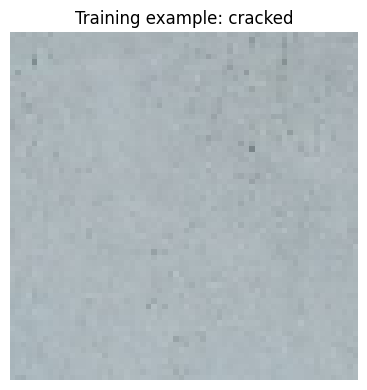

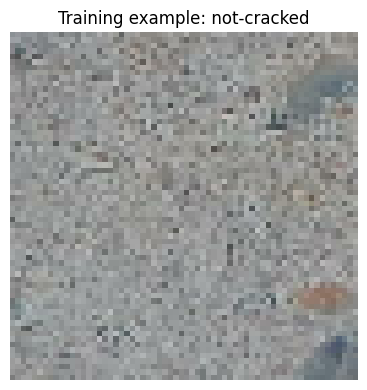

In [ ]:
# Make one separate figure for each class.
for class_number in [0, 1]:
    matching_positions = np.flatnonzero(train_labels == class_number)
    position = matching_positions[0]
    image, label = read_image(train_paths[position], train_labels[position])
    image, label = fun_preprocess_image(image, label)

    plt.figure(figsize=(4, 4))
    plt.imshow(image.numpy())
    plt.title("Training example: " + CLASS_NAMES[class_number])
    plt.axis("off")
    plt.tight_layout()

    # Save AFTER creating the figure and BEFORE closing it.
    plt.savefig(os.path.join(RUN_DIR, "example_class_" + str(class_number) + ".png"), dpi=150)
    plt.show()
    plt.close()

## 2. Model building
### 2.1 Understand the required layers

The **base** or **backbone** is MobileNetV2 without its original classifier. It converts pixels into learned feature maps.
**GlobalAveragePooling2D** averages each feature map over its spatial positions to make a shorter feature vector.
A **Dense** layer combines those features using trainable weights and biases.
**ReLU** keeps positive values and replaces negative ones with zero.
**Dropout(0.25)** randomly removes 25% of layer inputs during training, but not during prediction.
**L2 regularization** adds a small penalty for large hidden-layer weights.
The final **sigmoid** outputs one score between zero and one for **not cracked**, because that category has label 1.

The code `x = some_layer(x)` connects one operation to the next. This is the Keras **functional API**.
The input rescaling changes `[0, 1]` to `[-1, 1]`; it does not resize the image.
A warning about loading 224-based pretrained weights for 64 x 64 inputs is not itself an invalid input-shape error when `include_top=False`.

Resources: [functional API](https://keras.io/guides/functional_api/),
[MobileNetV2](https://keras.io/api/applications/mobilenet/mobilenet_models/),
[global average pooling](https://keras.io/api/layers/pooling_layers/global_average_pooling2d/),
[Dense](https://keras.io/api/layers/core_layers/dense/),
[Dropout](https://keras.io/api/layers/regularization_layers/dropout/),
[regularizers](https://keras.io/api/layers/regularizers/).

In [ ]:
# Load ImageNet-trained feature extraction layers, but remove the original classifier.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights="imagenet"
)

# Record its name so we can retrieve it safely after loading a saved model.
base_model_name = base_model.name

# Freeze the base during the first training stage.
# The newly created head will still be trainable.
base_model.trainable = False

# Declare one normalized RGB image as the model input.
inputs = tf.keras.Input(shape=(64, 64, 3), dtype="float32", name="normalized_rgb")

# The dataset supplies [0, 1]. MobileNetV2 expects [-1, 1].
# This layer computes 2*x - 1. Do not divide by 255 again here.
x = tf.keras.layers.Rescaling(2.0, offset=-1.0, name="mobilenet_input_range")(inputs)

# Keep the base's BatchNormalization statistics in inference mode.
# training=False does NOT prevent trainable convolution weights from updating later.
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

# First required hidden Dense layer and its dropout layer.
x = tf.keras.layers.Dense(
    512, activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(L2_STRENGTH),
    name="head_dense_512"
)(x)
x = tf.keras.layers.Dropout(0.25, name="head_dropout_1")(x)

# Second required hidden Dense layer and its dropout layer.
x = tf.keras.layers.Dense(
    256, activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(L2_STRENGTH),
    name="head_dense_256"
)(x)
x = tf.keras.layers.Dropout(0.25, name="head_dropout_2")(x)

# One sigmoid output represents the class-1, not-cracked score.
outputs = tf.keras.layers.Dense(
    1, activation="sigmoid", dtype="float32", name="not_cracked_score"
)(x)

# Connect the declared inputs and outputs into the complete model.
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="sdnet2018_mobilenetv2")
model.summary()

# Verify the required head configuration.
assert model.output_shape == (None, 1)
assert model.get_layer("head_dense_512").units == 512
assert model.get_layer("head_dense_256").units == 256
assert model.get_layer("head_dropout_1").rate == 0.25
assert model.get_layer("head_dropout_2").rate == 0.25

# Test the nontrainable input scaling at three simple values.
scaled_values = model.get_layer("mobilenet_input_range")(tf.constant([0.0, 0.5, 1.0]))
np.testing.assert_allclose(scaled_values.numpy(), [-1.0, 0.0, 1.0])

/tmp/ipykernel_1781/1069051726.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "sdnet2018_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalized_rgb (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_input_range           │ (None, 64, 64, 3)      │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_512 (Dense)          │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_256 (Dense)          │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ not_cracked_score (Dense)       │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,045,441 (11.62 MB)

 Trainable params: 787,457 (3.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Model training and evaluation
### 3.1 Set the optimizer, loss, metrics, and callbacks for transfer learning

**Adam** is the optimizer that updates trainable weights. **Binary cross-entropy (BCE)** penalizes disagreement between binary labels and sigmoid scores.
Training's `loss` includes the class weighting and L2 penalty. We also record `bce_unweighted`, which measures BCE without those additions.
That separate metric makes validation comparisons easier to interpret. It is not a percentage.

A **callback** performs a task during training. `ModelCheckpoint` saves the best validation-scoring model.
`ReduceLROnPlateau` makes the learning rate smaller after validation stops improving.
`CSVLogger` records the epoch history, and `TerminateOnNaN` stops an invalid nonfinite-loss run.
We do not add EarlyStopping here because the worked solution is designed to complete five plus three epochs.
The explicit epoch budgets limit training; failure checks are not instructions to ignore a failed run.

Resources: [Adam](https://keras.io/api/optimizers/adam/),
[BCE loss](https://keras.io/api/losses/probabilistic_losses/#binarycrossentropy-class),
[model training and weighting](https://keras.io/api/models/model_training_apis/),
[ModelCheckpoint](https://keras.io/api/callbacks/model_checkpoint/),
[ReduceLROnPlateau](https://keras.io/api/callbacks/reduce_lr_on_plateau/).

In [ ]:
# Compile describes HOW the model should learn; it does not start training.
# jit_compile=False avoids requiring XLA compilation for this introductory example.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TRANSFER_LEARNING_RATE),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=THRESHOLD),
        tf.keras.metrics.BinaryCrossentropy(name="bce_unweighted"),
        tf.keras.metrics.AUC(name="roc_auc_not_cracked")
    ],
    jit_compile=False
)

# Every run has new checkpoint paths. A file from an old run cannot be selected.
transfer_checkpoint = os.path.join(RUN_DIR, "best_transfer.keras")
fine_checkpoint = os.path.join(RUN_DIR, "best_fine.keras")

# Save and adjust learning rate using VALIDATION BCE, never test performance.
transfer_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        transfer_checkpoint, monitor="val_bce_unweighted", mode="min",
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_bce_unweighted", mode="min", factor=0.5,
        patience=1, min_lr=0.0000001, verbose=1
    ),
    tf.keras.callbacks.CSVLogger(os.path.join(RUN_DIR, "history_transfer.csv")),
    tf.keras.callbacks.TerminateOnNaN()
]

### 3.2 Train the head for five epochs

An **epoch** is one pass through the training dataset. A **batch** is one small group used in an update.
The model sees augmented training images, but unaugmented validation images.
Only the head's weights are updated in this stage.
`history_transfer` stores this stage's measurements; it will not be overwritten by fine-tuning.

Resource: [Model.fit](https://keras.io/api/models/model_training_apis/#fit-method).

In [ ]:
# fit starts training. verbose=2 prints a compact summary for each epoch.
history_transfer = model.fit(
    data_tr,
    validation_data=data_val,
    epochs=TRANSFER_EPOCHS,
    class_weight=class_weight,
    callbacks=transfer_callbacks,
    verbose=2
)

# Stop rather than silently treat an incomplete run as a completed assignment.
assert len(history_transfer.history["loss"]) == TRANSFER_EPOCHS
assert np.all(np.isfinite(history_transfer.history["loss"]))
assert np.all(np.isfinite(history_transfer.history["val_bce_unweighted"]))
assert os.path.isfile(transfer_checkpoint)

print("Completed transfer-learning epochs:", len(history_transfer.history["loss"]))

Epoch 1/5

Epoch 1: val_bce_unweighted improved from None to 0.43090, saving model to /content/assignment2_solution/runs/1790248322799944549/best_transfer.keras

Epoch 1: finished saving model to /content/assignment2_solution/runs/1790248322799944549/best_transfer.keras
4487/4487 - 95s - 21ms/step - accuracy: 0.7262 - bce_unweighted: 0.5811 - loss: 0.6583 - roc_auc_not_cracked: 0.7603 - val_accuracy: 0.8308 - val_bce_unweighted: 0.4309 - val_loss: 0.4867 - val_roc_auc_not_cracked: 0.8113 - learning_rate: 0.0010
Epoch 2/5

Epoch 2: val_bce_unweighted did not improve from 0.43090

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
4487/4487 - 64s - 14ms/step - accuracy: 0.7646 - bce_unweighted: 0.5432 - loss: 0.5965 - roc_auc_not_cracked: 0.7895 - val_accuracy: 0.6831 - val_bce_unweighted: 0.6286 - val_loss: 0.6698 - val_roc_auc_not_cracked: 0.8241 - learning_rate: 0.0010
Epoch 3/5

Epoch 3: val_bce_unweighted did not improve from 0.43090

Epoch 3: ReduceLROnPlat

### 3.3 Reload the best head-stage model and unfreeze from block 14

The last epoch is not necessarily the best epoch. We start fine-tuning from the saved checkpoint with the lowest validation BCE.
We retrieve the backbone **from the reloaded model**, not from an old variable pointing to a different model instance.
Only convolutional layers from block 14 onward become trainable; earlier layers and BatchNormalization stay frozen.
A small before/after check will confirm that one trainable convolution actually changes during fine-tuning.

Resources: [saving/loading models](https://keras.io/api/models/model_saving_apis/model_saving_and_loading/),
[fine-tuning and BatchNormalization](https://keras.io/guides/transfer_learning/).

In [ ]:
# Load the saved architecture and weights. We will compile for the new stage ourselves.
model = tf.keras.models.load_model(transfer_checkpoint, compile=False)
base_model = model.get_layer(base_model_name)

# Make the base available for selective fine-tuning.
base_model.trainable = True
start_fine_tuning = False

# Use a straightforward loop rather than relying on a guessed layer number.
for layer in base_model.layers:
    if layer.name.startswith("block_14_"):
        start_fine_tuning = True

    # Before block 14, start_fine_tuning is False; from block 14 onward it is True.
    layer.trainable = start_fine_tuning

    # Keep BatchNormalization weights/statistics frozen in both parts.
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

assert start_fine_tuning, "The required block 14 was not found."

# Save one convolution's current weights for a later comparison.
tracked_layer = base_model.get_layer("block_14_expand")
weights_before_fine_tuning = tracked_layer.kernel.numpy().copy()

# Save one frozen BatchNormalization layer's statistics too.
tracked_bn = base_model.get_layer("block_14_expand_BN")
bn_mean_before = tracked_bn.moving_mean.numpy().copy()
bn_variance_before = tracked_bn.moving_variance.numpy().copy()

print("Fine-tuning starts at block_14_expand.")
print("New initial learning rate:", FINE_TUNE_LEARNING_RATE)

Fine-tuning starts at block_14_expand.
New initial learning rate: 1e-05


### 3.4 Recompile and fine-tune for three more epochs

Changing `layer.trainable` requires recompiling before the next `fit` call.
We create a new Adam optimizer and new metric objects for this stage.
`initial_epoch=5` and `epochs=8` mean run global epochs 6, 7, and 8, **not eight additional epochs**.
This is the only fine-tuning call in the notebook.

In [ ]:
# Recompile AFTER choosing the trainable layers.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=THRESHOLD),
        tf.keras.metrics.BinaryCrossentropy(name="bce_unweighted"),
        tf.keras.metrics.AUC(name="roc_auc_not_cracked")
    ],
    jit_compile=False
)

# Use NEW callbacks, with a separate checkpoint and history file.
fine_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        fine_checkpoint, monitor="val_bce_unweighted", mode="min",
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_bce_unweighted", mode="min", factor=0.5,
        patience=1, min_lr=0.0000001, verbose=1
    ),
    tf.keras.callbacks.CSVLogger(os.path.join(RUN_DIR, "history_fine.csv")),
    tf.keras.callbacks.TerminateOnNaN()
]

history_fine = model.fit(
    data_tr,
    validation_data=data_val,
    initial_epoch=TRANSFER_EPOCHS,
    epochs=TRANSFER_EPOCHS + FINE_TUNE_EPOCHS,
    class_weight=class_weight,
    callbacks=fine_callbacks,
    verbose=2
)

# Confirm the stage finished and produced finite measurements.
assert len(history_fine.history["loss"]) == FINE_TUNE_EPOCHS
assert np.all(np.isfinite(history_fine.history["loss"]))
assert np.all(np.isfinite(history_fine.history["val_bce_unweighted"]))
assert os.path.isfile(fine_checkpoint)

# Conv weights should change; frozen BatchNormalization statistics should not.
assert not np.array_equal(weights_before_fine_tuning, tracked_layer.kernel.numpy())
np.testing.assert_array_equal(bn_mean_before, tracked_bn.moving_mean.numpy())
np.testing.assert_array_equal(bn_variance_before, tracked_bn.moving_variance.numpy())
print("Three fine-tuning epochs completed; convolution updates and frozen BN verified.")

Epoch 6/8

Epoch 6: val_bce_unweighted improved from None to 0.41422, saving model to /content/assignment2_solution/runs/1790248322799944549/best_fine.keras

Epoch 6: finished saving model to /content/assignment2_solution/runs/1790248322799944549/best_fine.keras
4487/4487 - 88s - 20ms/step - accuracy: 0.7920 - bce_unweighted: 0.5066 - loss: 0.5666 - roc_auc_not_cracked: 0.8107 - val_accuracy: 0.8595 - val_bce_unweighted: 0.4142 - val_loss: 0.4545 - val_roc_auc_not_cracked: 0.8526 - learning_rate: 1.0000e-05
Epoch 7/8

Epoch 7: val_bce_unweighted did not improve from 0.41422

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
4487/4487 - 79s - 18ms/step - accuracy: 0.8062 - bce_unweighted: 0.4797 - loss: 0.5318 - roc_auc_not_cracked: 0.8333 - val_accuracy: 0.8306 - val_bce_unweighted: 0.4689 - val_loss: 0.5047 - val_roc_auc_not_cracked: 0.8606 - learning_rate: 1.0000e-05
Epoch 8/8

Epoch 8: val_bce_unweighted did not improve from 0.41422

Epoch 8: ReduceLROnPlat

### 3.5 Select the final checkpoint using validation only

We compare the best validation BCE from the two stages, not merely their last epochs.
Fine-tuning is allowed to lose this comparison. Selecting the head-stage checkpoint would still mean both required phases were performed.
`np.argmin` returns the position of the smallest number in an array or list.
We add one to turn zero-based positions into human-readable epoch numbers.
The test set is still not consulted.

In [ ]:
# Find the best recorded validation BCE in each stage.
best_transfer_bce = min(history_transfer.history["val_bce_unweighted"])
best_fine_bce = min(history_fine.history["val_bce_unweighted"])

best_transfer_epoch = int(np.argmin(history_transfer.history["val_bce_unweighted"])) + 1
best_fine_epoch = int(np.argmin(history_fine.history["val_bce_unweighted"])) + TRANSFER_EPOCHS + 1

print("Best transfer BCE:", round(best_transfer_bce, 6), "at epoch", best_transfer_epoch)
print("Best fine-tuning BCE:", round(best_fine_bce, 6), "at epoch", best_fine_epoch)

# Choose the better stage using ONLY the predeclared validation metric.
if best_fine_bce < best_transfer_bce:
    selected_path = fine_checkpoint
    selected_stage = "fine-tuning"
    selected_epoch = best_fine_epoch
else:
    selected_path = transfer_checkpoint
    selected_stage = "transfer learning"
    selected_epoch = best_transfer_epoch

# This selected model is used for ALL final training/validation/test comparisons.
model = tf.keras.models.load_model(selected_path, compile=False)
base_model = model.get_layer(base_model_name)
print("Selected stage:", selected_stage)
print("Selected global epoch:", selected_epoch)

with open(os.path.join(RUN_DIR, "selected_checkpoint.txt"), "w") as file:
    file.write("Stage: " + selected_stage + "\n")
    file.write("Global epoch: " + str(selected_epoch) + "\n")
    file.write("Selected using validation BCE only.\n")

Best transfer BCE: 0.430901 at epoch 1
Best fine-tuning BCE: 0.414223 at epoch 6
Selected stage: fine-tuning
Selected global epoch: 6


### 3.6 Inspect every layer in MobileNetV2 block 14

A **layer name** identifies one particular layer; its **class** identifies the kind of operation, such as `Conv2D` or `Add`.
The requested **input shape** describes tensor dimensions, not a name like `keras_tensor_24`.
The residual `Add` layer receives two tensors, so both shapes must be printed.
BatchNormalization has both trainable parameters and nontrainable state; `layer.weights` includes both kinds.
A layer with no weights is not missing information simply because its weight list is empty.

Resources: [Keras layer attributes](https://keras.io/api/layers/base_layer/),
[Add layer](https://keras.io/api/layers/merging_layers/add/).

In [ ]:
# Build a readable text report and save the same report to a file.
inspection_lines = []
number_of_block_layers = 0

for layer in base_model.layers:
    if layer.name.startswith("block_14_"):
        number_of_block_layers += 1
        inspection_lines.append("Layer name: " + layer.name)
        inspection_lines.append("Layer class: " + layer.__class__.__name__)

        # A single-input layer has one tensor; Add has a list of tensors.
        if isinstance(layer.input, (list, tuple)):
            input_shapes = []
            for input_tensor in layer.input:
                input_shapes.append(tuple(input_tensor.shape))
        else:
            input_shapes = [tuple(layer.input.shape)]

        inspection_lines.append("Input shape(s): " + str(input_shapes))

        if len(layer.weights) == 0:
            inspection_lines.append("Weights: none")
        else:
            for weight in layer.weights:
                inspection_lines.append("  Weight: " + weight.name + "; shape: " + str(tuple(weight.shape)))

        # Block 14's residual addition must report its TWO inputs.
        if layer.name == "block_14_add":
            assert len(input_shapes) == 2

        inspection_lines.append("")

assert number_of_block_layers == 9, "Review the block-14 structure for this model version."
inspection_text = "\n".join(inspection_lines)
print("Number of block-14 layers:", number_of_block_layers)
print(inspection_text)
with open(os.path.join(RUN_DIR, "block_14_inspection.txt"), "w") as file:
    file.write(inspection_text)

Number of block-14 layers: 9
Layer name: block_14_expand
Layer class: Conv2D
Input shape(s): [(None, 2, 2, 160)]
  Weight: kernel; shape: (1, 1, 160, 960)

Layer name: block_14_expand_BN
Layer class: BatchNormalization
Input shape(s): [(None, 2, 2, 960)]
  Weight: gamma; shape: (960,)
  Weight: beta; shape: (960,)
  Weight: moving_mean; shape: (960,)
  Weight: moving_variance; shape: (960,)

Layer name: block_14_expand_relu
Layer class: ReLU
Input shape(s): [(None, 2, 2, 960)]
Weights: none

Layer name: block_14_depthwise
Layer class: DepthwiseConv2D
Input shape(s): [(None, 2, 2, 960)]
  Weight: kernel; shape: (3, 3, 960, 1)

Layer name: block_14_depthwise_BN
Layer class: BatchNormalization
Input shape(s): [(None, 2, 2, 960)]
  Weight: gamma; shape: (960,)
  Weight: beta; shape: (960,)
  Weight: moving_mean; shape: (960,)
  Weight: moving_variance; shape: (960,)

Layer name: block_14_depthwise_relu
Layer class: ReLU
Input shape(s): [(None, 2, 2, 960)]
Weights: none

Layer name: block_1

### 3.7 Plot both training phases

We combine the two histories without overwriting either one. The vertical marker separates epochs 1-5 from epochs 6-8.
The BCE plot uses the **unweighted BCE metric**, not the class-weighted training objective.
Training is still measured with augmentation and dropout enabled; validation is measured without them.
Therefore, those curves are useful trends, not a perfectly controlled training/validation comparison.
The later clean evaluation uses identical inference conditions for the selected checkpoint.

Resources: [Matplotlib plotting](https://matplotlib.org/stable/tutorials/pyplot.html),
[saving figures](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html).

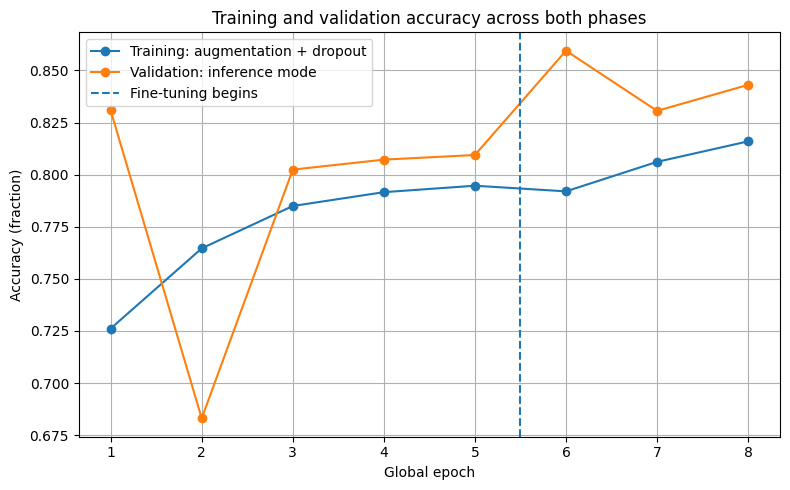

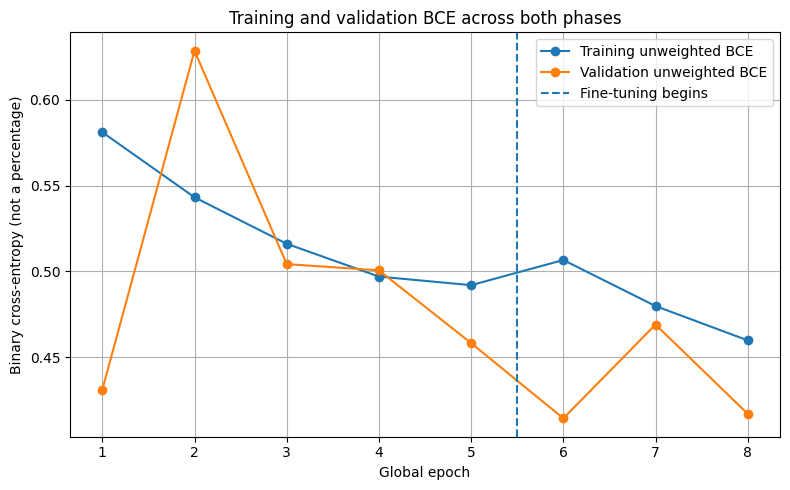

Epoch 1 : learning rate 1.000e-03
Epoch 2 : learning rate 1.000e-03
Epoch 3 : learning rate 5.000e-04
Epoch 4 : learning rate 2.500e-04
Epoch 5 : learning rate 1.250e-04
Epoch 6 : learning rate 1.000e-05
Epoch 7 : learning rate 1.000e-05
Epoch 8 : learning rate 5.000e-06


In [ ]:
# A Python list can be joined to another list with +.
# The two original history objects remain intact.
all_accuracy = history_transfer.history["accuracy"] + history_fine.history["accuracy"]
all_val_accuracy = history_transfer.history["val_accuracy"] + history_fine.history["val_accuracy"]
all_bce = history_transfer.history["bce_unweighted"] + history_fine.history["bce_unweighted"]
all_val_bce = history_transfer.history["val_bce_unweighted"] + history_fine.history["val_bce_unweighted"]
all_learning_rates = history_transfer.history["learning_rate"] + history_fine.history["learning_rate"]
epoch_numbers = np.arange(1, TRANSFER_EPOCHS + FINE_TUNE_EPOCHS + 1)

# First figure: accuracy trends.
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, all_accuracy, marker="o", label="Training: augmentation + dropout")
plt.plot(epoch_numbers, all_val_accuracy, marker="o", label="Validation: inference mode")
plt.axvline(5.5, linestyle="--", label="Fine-tuning begins")
plt.xlabel("Global epoch")
plt.ylabel("Accuracy (fraction)")
plt.title("Training and validation accuracy across both phases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "accuracy.png"), dpi=150)
plt.show()
plt.close()

# Second figure: unweighted data-fit BCE, without the L2 penalty.
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, all_bce, marker="o", label="Training unweighted BCE")
plt.plot(epoch_numbers, all_val_bce, marker="o", label="Validation unweighted BCE")
plt.axvline(5.5, linestyle="--", label="Fine-tuning begins")
plt.xlabel("Global epoch")
plt.ylabel("Binary cross-entropy (not a percentage)")
plt.title("Training and validation BCE across both phases")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "unweighted_bce.png"), dpi=150)
plt.show()
plt.close()

# Print tiny learning rates in scientific notation so they do not look like zero.
for position in range(len(epoch_numbers)):
    print("Epoch", epoch_numbers[position], ": learning rate", f"{all_learning_rates[position]:.3e}")

## Results and Discussion
### 3.8 Keep predictions paired with their true labels

The model returns a **class-1 score** `p_not_cracked`. The cracked score is `1 - p_not_cracked`.
A threshold converts scores into class labels. The scores themselves are retained for ROC-AUC and average precision.
Do not collect all labels in one shuffled pass and predictions in another: the orders can differ.
The function below predicts one batch and saves that very batch's labels immediately.

`predict_on_batch` performs prediction for one supplied batch in inference mode.
Using it inside this loop avoids building a custom training loop or a custom TensorFlow decorator.
`np.concatenate` joins the saved small arrays into one full array.

Resources: [predict_on_batch](https://keras.io/api/models/model_training_apis/#predict_on_batch-method),
[NumPy concatenate](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html).

In [ ]:
# This helper receives a dataset and the expected labels from its file list.
# It returns TWO arrays in exactly the same order: labels and class-1 scores.
def collect_paired_predictions(dataset, expected_labels, subset_name):
    label_batches = []
    score_batches = []

    for images, labels in dataset:
        # Predict these images and retain the labels from THIS SAME iteration.
        batch_scores = model.predict_on_batch(images)
        label_batches.append(labels.numpy().ravel())
        score_batches.append(np.asarray(batch_scores).ravel())

    # Join all batches, including the final partial batch.
    true_labels = np.concatenate(label_batches).astype(np.int32)
    not_cracked_scores = np.concatenate(score_batches).astype(np.float64)

    # Check lengths, ordering, and numerical validity.
    assert len(true_labels) == len(expected_labels)
    assert len(not_cracked_scores) == len(expected_labels)
    np.testing.assert_array_equal(true_labels, expected_labels)
    assert np.all(np.isfinite(not_cracked_scores)), "Predictions contain NaN or infinity."
    assert np.all(not_cracked_scores >= 0) and np.all(not_cracked_scores <= 1)
    print(subset_name, ": paired predictions for", len(true_labels), "images")
    return true_labels, not_cracked_scores

# The selected checkpoint is evaluated in identical, clean inference conditions.
y_train, p_train = collect_paired_predictions(data_tr_eval, train_labels, "Training")
y_val, p_val = collect_paired_predictions(data_val, val_labels, "Validation")
y_test, p_test = collect_paired_predictions(data_te, test_labels, "Test")

# Keep the raw scores so every test metric and plot uses exactly these predictions.
# No learning rate, checkpoint, or threshold is changed after looking at the test results.
for name, labels, scores in [("training", y_train, p_train),
                              ("validation", y_val, p_val),
                              ("test", y_test, p_test)]:
    rows = np.column_stack((labels, scores))
    np.savetxt(os.path.join(RUN_DIR, name + "_predictions.csv"), rows,
               delimiter=",", header="true_label,not_cracked_score", comments="")

Training : paired predictions for 35894 images
Validation : paired predictions for 8974 images
Test : paired predictions for 11217 images


### 3.9 Define the metrics before interpreting them

For the following crack-detection counts, **positive means cracked even though its stored label is 0**.
A **true positive (TP)** is a crack correctly detected; a **false negative (FN)** is a missed crack.
A **false positive (FP)** is a non-cracked image incorrectly flagged; a **true negative (TN)** is correctly identified non-cracked concrete.

\[
\text{Precision}_{crack}=\frac{TP}{TP+FP},\quad
\text{Recall}_{crack}=\frac{TP}{TP+FN},\quad
F1_{crack}=\frac{2TP}{2TP+FP+FN}.
\]

Accuracy is the fraction of all images classified correctly. **Balanced accuracy** averages the two class recalls,
and **macro F1** gives both classes equal importance. **ROC-AUC** measures ranking across score thresholds;
**average precision** summarizes a precision-recall curve. Neither is calculated from already thresholded predictions.
When no cracks are predicted, cracked precision is undefined; we explicitly display zero by convention and say so.
Unweighted BCE measures data fit and is **not a percentage**. Class-weighted learning does not guarantee calibrated scores.

Resources: [classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics),
[precision/recall/F1](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html),
[ROC-AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html),
[average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html),
[log loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html).

In [ ]:
# The same function evaluates each subset using the same definitions.
def calculate_metrics(true_labels, not_cracked_scores):
    # Flatten inputs to one-dimensional arrays.
    true_labels = np.asarray(true_labels).astype(np.int32).ravel()
    not_cracked_scores = np.asarray(not_cracked_scores).astype(np.float64).ravel()
    assert len(true_labels) == len(not_cracked_scores)
    assert np.array_equal(np.unique(true_labels), [0, 1]), "Both classes are needed."
    assert np.all(np.isfinite(not_cracked_scores))
    assert np.all(not_cracked_scores >= 0) and np.all(not_cracked_scores <= 1)

    # Predict 1 only ABOVE the threshold. A tie is assigned to cracked/class 0.
    predicted_labels = (not_cracked_scores > THRESHOLD).astype(np.int32)

    # ROC and precision-recall routines will use 1 to mean cracked internally.
    cracked_labels = 1 - true_labels
    cracked_scores = 1.0 - not_cracked_scores

    # Rows = actual labels; columns = predicted labels; order is [cracked, not cracked].
    matrix = metrics.confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

    # A dictionary groups the named results so we can look them up later.
    results = {}
    results["accuracy"] = metrics.accuracy_score(true_labels, predicted_labels)
    results["balanced_accuracy"] = metrics.balanced_accuracy_score(true_labels, predicted_labels)
    results["cracked_precision"] = metrics.precision_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    results["cracked_recall"] = metrics.recall_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    results["cracked_f1"] = metrics.f1_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    results["macro_f1"] = metrics.f1_score(true_labels, predicted_labels, average="macro", zero_division=0)
    results["roc_auc_cracked"] = metrics.roc_auc_score(cracked_labels, cracked_scores)
    results["average_precision_cracked"] = metrics.average_precision_score(cracked_labels, cracked_scores)
    results["bce_unweighted"] = metrics.log_loss(true_labels, not_cracked_scores, labels=[0, 1])

    # These four entries have the engineering convention: cracks are positive.
    results["detected_cracks"] = int(matrix[0, 0])
    results["missed_cracks"] = int(matrix[0, 1])
    results["false_alarms"] = int(matrix[1, 0])
    results["correct_non_cracks"] = int(matrix[1, 1])

    # Independently check that the matrix and accuracy agree.
    correct_predictions = matrix[0, 0] + matrix[1, 1]
    assert np.isclose(results["accuracy"], correct_predictions / np.sum(matrix))
    return results, predicted_labels, matrix

# Evaluate the same selected model on all three clean datasets.
train_metrics, train_predicted, train_matrix = calculate_metrics(y_train, p_train)
val_metrics, val_predicted, val_matrix = calculate_metrics(y_val, p_val)
test_metrics, test_predicted, test_matrix = calculate_metrics(y_test, p_test)

# Display the test classification report with real category names.
print("TEST CLASSIFICATION REPORT: class 0 = cracked")
print(metrics.classification_report(
    y_test, test_predicted, labels=[0, 1], target_names=CLASS_NAMES,
    digits=4, zero_division=0
))

# Explain an undefined precision rather than hide its meaning.
if np.sum(test_predicted == 0) == 0:
    print("No cracked predictions: cracked precision is undefined and is displayed as 0.")

# Keep loss units separate from percentage-style metrics.
print("Test ROC-AUC for cracks:", round(test_metrics["roc_auc_cracked"], 4))
print("Test average precision for cracks:", round(test_metrics["average_precision_cracked"], 4))
print("Test unweighted BCE, NOT a percentage:", round(test_metrics["bce_unweighted"], 4))
print("Confusion matrix: rows actual, columns predicted; order [cracked, not cracked]")
print(test_matrix)

TEST CLASSIFICATION REPORT: class 0 = cracked
              precision    recall  f1-score   support

     cracked     0.5068    0.6197    0.5576      1696
 not-cracked     0.9295    0.8926    0.9106      9521

    accuracy                         0.8513     11217
   macro avg     0.7181    0.7561    0.7341     11217
weighted avg     0.8655    0.8513    0.8572     11217

Test ROC-AUC for cracks: 0.8461
Test average precision for cracks: 0.6361
Test unweighted BCE, NOT a percentage: 0.4258
Confusion matrix: rows actual, columns predicted; order [cracked, not cracked]
[[1051  645]
 [1023 8498]]


### 3.10 Compare with a simple baseline

A **baseline** is a simple reference method. Here it always predicts the majority training class, not cracked.
Its constant class-1 score is the fraction of non-cracked images in the **training** subset.
We do not estimate a new prior or choose the model from test labels.
High accuracy can coexist with zero crack detection, so compare recall and balanced accuracy as well as accuracy.
The recorded reference run later illustrates exactly this tradeoff.

In [ ]:
# Calculate the class-1 fraction using TRAINING labels only.
training_not_cracked_fraction = float(np.mean(train_labels == 1))
assert training_not_cracked_fraction > THRESHOLD, "This baseline assumes not cracked is the majority."

# np.full makes an array containing the same score for every test image.
baseline_scores = np.full(len(y_test), training_not_cracked_fraction)
baseline_metrics, baseline_predicted, baseline_matrix = calculate_metrics(y_test, baseline_scores)

# Show the same quantities for the baseline and the selected neural network.
metric_names = ["accuracy", "balanced_accuracy", "cracked_precision", "cracked_recall",
                "cracked_f1", "macro_f1", "roc_auc_cracked", "average_precision_cracked", "bce_unweighted"]
print("Metric                          Baseline      Selected model")
for metric_name in metric_names:
    baseline_value = baseline_metrics[metric_name]
    model_value = test_metrics[metric_name]
    print(f"{metric_name:<31} {baseline_value:>8.4f}       {model_value:>8.4f}")

# Save a simple numerical summary without requiring another table library.
summary_rows = []
for metric_name in metric_names:
    summary_rows.append([metric_name, baseline_metrics[metric_name], test_metrics[metric_name]])
np.savetxt(os.path.join(RUN_DIR, "test_comparison.csv"), np.array(summary_rows), fmt="%s",
           delimiter=",", header="metric,majority_baseline,selected_model", comments="")

Metric                          Baseline      Selected model
accuracy                          0.8488         0.8513
balanced_accuracy                 0.5000         0.7561
cracked_precision                 0.0000         0.5068
cracked_recall                    0.0000         0.6197
cracked_f1                        0.0000         0.5576
macro_f1                          0.4591         0.7341
roc_auc_cracked                   0.5000         0.8461
average_precision_cracked         0.1512         0.6361
bce_unweighted                    0.4248         0.4258


### 3.11 Plot the confusion matrix from the same test predictions

Rows show the true category; columns show the predicted category.
The upper-right entry counts missed cracks. The lower-left entry counts false crack alarms.
The numbers in the plot, the printed matrix, and the report all come from `test_matrix`.

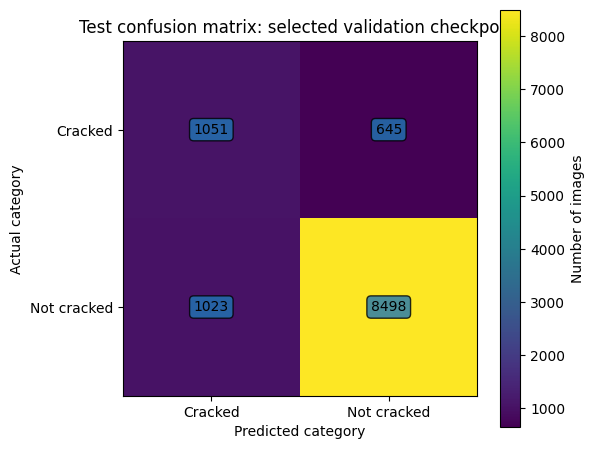

In [ ]:
# The plotting code does not run prediction again.
plt.figure(figsize=(6, 5))
plt.imshow(test_matrix)
plt.colorbar(label="Number of images")
plt.xticks([0, 1], ["Cracked", "Not cracked"])
plt.yticks([0, 1], ["Cracked", "Not cracked"])
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.title("Test confusion matrix: selected validation checkpoint")

# Put each count inside its corresponding square.
for row in range(2):
    for column in range(2):
        plt.text(column, row, str(test_matrix[row, column]), ha="center", va="center",
                 bbox={"boxstyle": "round", "alpha": 0.8})

plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "test_confusion_matrix.png"), dpi=150)
plt.show()
plt.close()

### 3.12 Plot ranking performance using continuous cracked scores

ROC plots true-positive rate against false-positive rate as the threshold changes.
The precision-recall plot asks how many detected cracks are genuine and how many real cracks are detected.
Average precision is calculated directly from the scores; it is not simply the label accuracy.
These test plots are descriptive only. They are **not used to tune the threshold on this test set**.

Resources: [ROC curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html),
[precision-recall curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html).

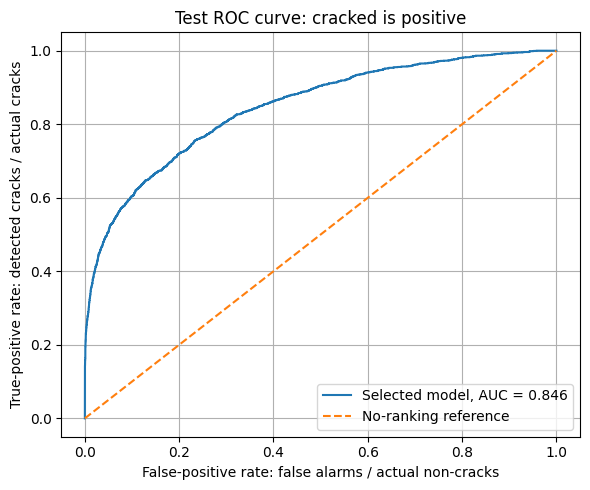

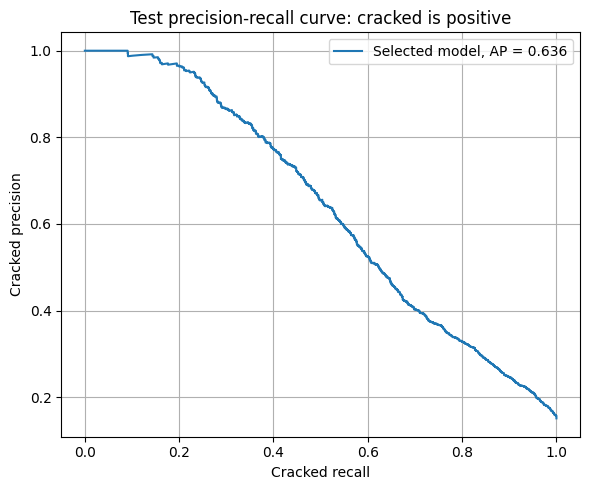

In [ ]:
# Convert both labels and scores so that 1 means cracked for these curve functions.
test_cracked_labels = 1 - y_test
test_cracked_scores = 1.0 - p_test

# First curve: ROC using the continuous cracked scores.
false_positive_rate, true_positive_rate, roc_thresholds = metrics.roc_curve(
    test_cracked_labels, test_cracked_scores
)
plt.figure(figsize=(6, 5))
plt.plot(false_positive_rate, true_positive_rate,
         label=f"Selected model, AUC = {test_metrics['roc_auc_cracked']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="No-ranking reference")
plt.xlabel("False-positive rate: false alarms / actual non-cracks")
plt.ylabel("True-positive rate: detected cracks / actual cracks")
plt.title("Test ROC curve: cracked is positive")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "test_roc.png"), dpi=150)
plt.show()
plt.close()

# Second curve: precision versus recall, from the SAME stored scores.
curve_precision, curve_recall, pr_thresholds = metrics.precision_recall_curve(
    test_cracked_labels, test_cracked_scores
)
plt.figure(figsize=(6, 5))
plt.plot(curve_recall, curve_precision,
         label=f"Selected model, AP = {test_metrics['average_precision_cracked']:.3f}")
plt.xlabel("Cracked recall")
plt.ylabel("Cracked precision")
plt.title("Test precision-recall curve: cracked is positive")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RUN_DIR, "test_precision_recall.png"), dpi=150)
plt.show()
plt.close()

### 3.13 Write the numerical discussion from this execution

The next cell inserts the actual computed values into a report paragraph.
It does not hard-code a desired accuracy or claim that a favorable result is guaranteed.
The saved reference run is discussed separately below; a new run should be interpreted using its own outputs.

In [ ]:
# Count actual cracks and calculate the signed difference from the baseline.
actual_test_cracks = int(np.sum(y_test == 0))
accuracy_difference = 100 * (test_metrics["accuracy"] - baseline_metrics["accuracy"])

# Triple quotes allow a readable multi-line report string.
# Expressions inside braces are replaced by the actual values from THIS run.
results_text = f"""
RESULTS AND DISCUSSION: CURRENT EXECUTION

The archive contains {len(all_train_paths) + len(test_paths):,} images.
We used {len(train_paths):,} training images, {len(val_paths):,} validation images,
and {len(test_paths):,} test images. Both classes were verified in every subset.
Five transfer-learning epochs and three fine-tuning epochs completed.
The selected checkpoint is from {selected_stage}, global epoch {selected_epoch},
chosen by validation unweighted BCE rather than test performance.

Test accuracy is {test_metrics['accuracy']:.2%}, compared with
{baseline_metrics['accuracy']:.2%} for always predicting not cracked.
The signed difference is {accuracy_difference:+.2f} percentage points.
Balanced accuracy is {test_metrics['balanced_accuracy']:.4f}; macro F1 is {test_metrics['macro_f1']:.4f}.
Cracked precision is {test_metrics['cracked_precision']:.4f}, cracked recall is
{test_metrics['cracked_recall']:.4f}, and cracked F1 is {test_metrics['cracked_f1']:.4f}.

The model detected {test_metrics['detected_cracks']:,} of {actual_test_cracks:,} actual cracks,
missed {test_metrics['missed_cracks']:,}, and generated {test_metrics['false_alarms']:,} false alarms.
Cracked ROC-AUC is {test_metrics['roc_auc_cracked']:.4f} and average precision is
{test_metrics['average_precision_cracked']:.4f}. These use paired, continuous scores.
Unweighted test BCE is {test_metrics['bce_unweighted']:.4f}, not a percentage.

These are image-patch results. They do not establish crack location, crack width,
structural safety, or performance on independent inspection sites.
The experiment does not include an unweighted control run, so it cannot isolate
how much of the observed behavior was caused by class weighting.
"""
print(results_text)
with open(os.path.join(RUN_DIR, "results_discussion.txt"), "w") as file:
    file.write(results_text)


RESULTS AND DISCUSSION: CURRENT EXECUTION

The archive contains 56,085 images.
We used 35,894 training images, 8,974 validation images,
and 11,217 test images. Both classes were verified in every subset.
Five transfer-learning epochs and three fine-tuning epochs completed.
The selected checkpoint is from fine-tuning, global epoch 6,
chosen by validation unweighted BCE rather than test performance.

Test accuracy is 85.13%, compared with
84.88% for always predicting not cracked.
The signed difference is +0.25 percentage points.
Balanced accuracy is 0.7561; macro F1 is 0.7341.
Cracked precision is 0.5068, cracked recall is
0.6197, and cracked F1 is 0.5576.

The model detected 1,051 of 1,696 actual cracks,
missed 645, and generated 1,023 false alarms.
Cracked ROC-AUC is 0.8461 and average precision is
0.6361. These use paired, continuous scores.
Unweighted test BCE is 0.4258, not a percentage.

These are image-patch results. They do not establish crack location, crack width,
structural s

## 4. Overfitting and generalization

**Overfitting** means that a model learns features of its training data that do not transfer well to held-out examples.
A falling training loss accompanied by rising validation loss can be a warning, but a curve alone does not prove memorization.
A mistaken split, different class proportions, or unstable optimization can also create large gaps.
We therefore check both the within-stage learning trends and the selected checkpoint under clean inference.

The next cell reports observations without inventing a numerical rule that declares a model definitely overfit or definitely free of overfitting.
It compares the same model on the three subsets without augmentation or dropout.
Training loss used during `fit` was class-weighted, so we compare **unweighted BCE** here instead.

For generalization, we report the observed missed-crack rate and false alarms at the chosen threshold.
That answers the narrow question of performance on the supplied held-out patches, not the stronger question of performance at new sites.
A source-photo/structure-grouped study is needed to examine that stronger claim.

In [ ]:
# Compare epochs only WITHIN each stage.
# The transition from head training to fine-tuning changes the training conditions.
warning_epochs = []
for stage_history, epoch_offset in [(history_transfer, 0), (history_fine, TRANSFER_EPOCHS)]:
    training_bce = stage_history.history["bce_unweighted"]
    validation_bce = stage_history.history["val_bce_unweighted"]
    for position in range(1, len(training_bce)):
        training_decreased = training_bce[position] < training_bce[position - 1]
        validation_increased = validation_bce[position] > validation_bce[position - 1]
        if training_decreased and validation_increased:
            warning_epochs.append(position + epoch_offset + 1)

if len(warning_epochs) > 0:
    trend_text = "Training BCE fell while validation BCE rose at global epochs " + str(warning_epochs) + "."
else:
    trend_text = "No adjacent within-stage epoch showed falling training BCE and rising validation BCE."

# Clean inference comparisons use the SAME selected checkpoint and data treatment.
accuracy_gap = 100 * (train_metrics["accuracy"] - val_metrics["accuracy"])
bce_gap = val_metrics["bce_unweighted"] - train_metrics["bce_unweighted"]
miss_rate = 1 - test_metrics["cracked_recall"]

analysis_text = f"""
OVERFITTING AND GENERALIZATION: CURRENT EXECUTION

{trend_text}
This is a descriptive observation, not proof of memorization or its absence.
For the selected checkpoint, clean training accuracy is {train_metrics['accuracy']:.2%},
validation accuracy is {val_metrics['accuracy']:.2%}, and test accuracy is {test_metrics['accuracy']:.2%}.
Training minus validation accuracy is {accuracy_gap:+.2f} percentage points.
Validation minus training unweighted BCE is {bce_gap:+.4f}.
Consider these clean comparisons alongside the complete curves and class-specific errors.
A single short run cannot prove that overfitting is absent or identify a unique cause.

The test missed-crack rate is {miss_rate:.2%}, with {test_metrics['false_alarms']:,} false alarms.
These errors are the direct threshold-specific limitations for this crack-detection task.
There is no field acceptance requirement in this assignment that would justify calling
this model safe or ready for deployment. Independent-site performance remains unverified.
Class weighting, resolution, and short training are possible influences, but their
individual effects require controlled comparisons rather than conclusions from this run alone.
"""
print(analysis_text)
with open(os.path.join(RUN_DIR, "overfitting_generalization.txt"), "w") as file:
    file.write(analysis_text)


OVERFITTING AND GENERALIZATION: CURRENT EXECUTION

Training BCE fell while validation BCE rose at global epochs [2, 7].
This is a descriptive observation, not proof of memorization or its absence.
For the selected checkpoint, clean training accuracy is 85.46%,
validation accuracy is 85.95%, and test accuracy is 85.13%.
Training minus validation accuracy is -0.49 percentage points.
Validation minus training unweighted BCE is -0.0055.
Consider these clean comparisons alongside the complete curves and class-specific errors.
A single short run cannot prove that overfitting is absent or identify a unique cause.

The test missed-crack rate is 38.03%, with 1,023 false alarms.
These errors are the direct threshold-specific limitations for this crack-detection task.
There is no field acceptance requirement in this assignment that would justify calling
this model safe or ready for deployment. Independent-site performance remains unverified.
Class weighting, resolution, and short training are po

### Proposed improvements and their tradeoffs

**Obtain more varied cracked examples or oversample only the training subset.** This can expose the model to more crack appearances.
Repeating existing cracked images does not create new information and can encourage overfitting.
Collecting examples from new structures is more informative but requires annotation and quality checks.
An absent class must first be restored to training; neither weighting nor more epochs can teach from examples that are not there.

**Compare class weights and decision thresholds on validation data.** Class weighting changes what errors the optimizer emphasizes during learning.
A threshold changes the decision made from an already trained model's score.
For this class-1 output, increasing the non-cracked threshold makes it easier to predict cracked, so recall cannot decrease for fixed scores,
but false alarms can increase and precision need not improve. Tune on validation only, then freeze the choice before an independent final test.
Our reported test curves are descriptive; we have not tuned their threshold after seeing test results.

**Compare a smaller fine-tuning region, a lower learning rate, or different regularization strengths.** These may control unstable changes or an excessive training/validation gap.
Too little fine-tuning can prevent useful adaptation; too much regularization can suppress useful signals.
Make one controlled change at a time and compare validation results. More epochs are not automatically a remedy for overfitting.
For the submitted assignment, retain the required 5 + 3 schedule; longer runs belong to a separately documented extension.

**Study the data and error patterns.** Check label quality and examine false negatives and false positives without treating the final test as a repeated tuning target.
Future work could examine performance by deck, wall, or pavement, provided trustworthy category metadata exist.
Source-photo/structure-grouped splits and a new-site test would better evaluate broader generalization.
Different file names alone do not establish those forms of independence.

**Keep engineering scope explicit.** Small cracks can become harder to see after resizing, but this run does not isolate that effect.
A future resolution comparison would require additional compute and would be a documented extension beyond the assignment's supplied 64 x 64 processing.
Image-level labels do not provide crack localization, dimensional measurement, or structural safety verification.

Resources: [threshold selection](https://scikit-learn.org/stable/modules/classification_threshold.html),
[cross-validation and grouped splitting](https://scikit-learn.org/stable/modules/cross_validation.html),
[transfer learning](https://keras.io/guides/transfer_learning/).

## Conclusion

This solution demonstrates the required MobileNetV2 feature extractor and functional binary-classification head.
It uses the supplied course images, counts their labels with glob, and creates a fixed two-class training/validation split.
The experiment trains the head for five epochs and fine-tunes from block 14 for three additional epochs with a smaller learning rate.
It selects model weights using validation data, preserves every evaluation image-label pair, and reports class-specific errors.
The complete block-14 inspection includes both inputs of the residual addition layer.
The recorded reference shows that useful crack detection can coexist with lower overall accuracy than an always-non-cracked baseline.
It also demonstrates why validation-selected weights and a reasoned discussion matter as much as executing the training code.
A new execution must use its own measured results, and neither the reference nor this implementation establishes an error-free inspection system.

### Pros
- Transfer learning reuses learned features while limiting the compute needed for a short educational experiment.
- Explicit class checks, validation-only selection, paired predictions, and several metrics make the conclusions traceable to observations.

### Cons
- Class imbalance, one seed, a small image resolution, and a short training budget limit what this experiment can establish.
- The recorded model missed many cracks and produced false alarms; independent-structure and field performance were not verified.

### Improvements
- Compare training-only sampling/weights, fine-tuning depth, and learning rate with validation-controlled experiments.
- Study threshold tradeoffs and obtain independent, source-grouped data before making broader generalization claims.

### Current-run closing summary and completion checks

This final code cell writes a short conclusion using the values computed by your execution.
The checks verify important implementation conditions; they are not an automatic grade or an accuracy target.

In [ ]:
# Confirm that all required stages and all test examples were completed.
assert len(history_transfer.history["loss"]) == 5
assert len(history_fine.history["loss"]) == 3
assert len(y_test) == len(test_paths)
assert int(np.sum(test_matrix)) == len(y_test)
assert number_of_block_layers == 9

# Save the selected model once more under a clearly named file.
model.save(os.path.join(RUN_DIR, "selected_model.keras"))

conclusion_text = f"""
CONCLUSION: CURRENT EXECUTION

The validation-selected {selected_stage} checkpoint from global epoch {selected_epoch}
achieved {test_metrics['accuracy']:.2%} test accuracy and
{test_metrics['balanced_accuracy']:.4f} balanced accuracy.
Cracked recall was {test_metrics['cracked_recall']:.2%} and cracked F1 was {test_metrics['cracked_f1']:.4f}.
It detected {test_metrics['detected_cracks']:,} cracks, missed {test_metrics['missed_cracks']:,},
and produced {test_metrics['false_alarms']:,} false alarms.
The always-not-cracked baseline accuracy was {baseline_metrics['accuracy']:.2%}.
Both training phases and the complete block-14 inspection were completed.
These patch-level findings do not establish structural safety or new-site performance.
"""
print(conclusion_text)
with open(os.path.join(RUN_DIR, "conclusion.txt"), "w") as file:
    file.write(conclusion_text)

print("Run checks passed. This is not an automatic grade.")
print("Supplemental files are in:", RUN_DIR)
print("Save the executed .ipynb with its outputs before disconnecting.")


CONCLUSION: CURRENT EXECUTION

The validation-selected fine-tuning checkpoint from global epoch 6
achieved 85.13% test accuracy and
0.7561 balanced accuracy.
Cracked recall was 61.97% and cracked F1 was 0.5576.
It detected 1,051 cracks, missed 645,
and produced 1,023 false alarms.
The always-not-cracked baseline accuracy was 84.88%.
Both training phases and the complete block-14 inspection were completed.
These patch-level findings do not establish structural safety or new-site performance.

Run checks passed. This is not an automatic grade.
Supplemental files are in: /content/assignment2_solution/runs/1790248322799944549
Save the executed .ipynb with its outputs before disconnecting.


## Saving work and avoiding wasted GPU allocation

Use **File > Download > Download .ipynb** after the run and preserve the results in that notebook.
The files printed above are in Colab's temporary runtime storage; download desired checkpoints/CSV/PNG files from its Files panel before ending the session.
Do not repeat the fine-tuning cell merely to recreate a plot: rerun the plotting cell instead.
The final optional code below is off by default because disconnecting can destroy access to unsaved runtime files.
After saving, either disconnect through Colab or deliberately turn this switch on.

Resource: [Colab runtime and resource FAQ](https://research.google.com/colaboratory/faq.html).

In [ ]:
# Leave this False while you are studying the results or saving files.
# Change it to True only after the executed notebook and desired files are saved.
DISCONNECT_AFTER_SAVING = False

if DISCONNECT_AFTER_SAVING:
    from google.colab import runtime
    tf.keras.backend.clear_session()
    runtime.unassign()
else:
    print("Runtime left connected. Save your work, then disconnect when finished.")

Runtime left connected. Save your work, then disconnect when finished.


## Assignment checklist and resource index

| Assignment component | Where the solution addresses it |
| :--- | :--- |
| Download SDNET2018 and count class 0/class 1 with glob | Sections 1.3-1.4 |
| Identify the cracked label and assess balance | Sections 1.4-1.6 |
| TensorFlow image processing, separate validation, GPU | Sections 1.2 and 1.5-1.9 |
| Required functional MobileNetV2 architecture | Section 2.1 |
| Loss, optimizer, regularization, callbacks | Sections 2.1 and 3.1 |
| Five transfer-learning and three fine-tuning epochs | Sections 3.2-3.4 |
| Test metrics, matrix, and correct label pairing | Sections 3.8-3.13 |
| Layer name, class, input shape(s), weight names/shapes in block 14 | Section 3.6 |
| Explain overfitting, generalization, and proposed remedies | Section 4 and recorded-reference interpretation |
| Dataset sources, methods, findings, conclusion, pros/cons/improvements | Markdown report throughout |
| Save the completed notebook and release runtime deliberately | Final saving/resource section |

### Additional official reading

[Python tutorial](https://docs.python.org/3/tutorial/) | [NumPy beginner guide](https://numpy.org/doc/stable/user/absolute_beginners.html) |
[Matplotlib tutorials](https://matplotlib.org/stable/tutorials/index.html) |
[TensorFlow beginner introduction](https://www.tensorflow.org/tutorials/quickstart/beginner) |
[Keras functional API](https://keras.io/guides/functional_api/) |
[Keras model saving](https://keras.io/api/models/model_saving_apis/model_saving_and_loading/) |
[scikit-learn evaluation guide](https://scikit-learn.org/stable/modules/model_evaluation.html) |
[SDNET2018 university record](https://digitalcommons.usu.edu/all_datasets/48/) |
[assignment-linked Kaggle page](https://www.kaggle.com/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images).
